In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [2]:
# Step 1: Load the dataset
file_path = '/content/sample_data/mb_tumor.data'
columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]  # 30 features
data = pd.read_csv(file_path, header=None, names=columns)

In [3]:
# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)  # Optional: Limit to 10 rows

# Display the first 10 rows of the dataset
print("First 10 rows of the dataset:")
print(data.head(10))

First 10 rows of the dataset:
         ID Diagnosis  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   
5    843786         M      12.45      15.70      82.57      477.1    0.12780   
6    844359         M      18.25      19.98     119.60     1040.0    0.09463   
7  84458202         M      13.71      20.83      90.20      577.9    0.11890   
8    844981         M      13.00      21.82      87.50      519.8    0.12730   
9  84501001         M      12.46      24.04      83.97      475.9    0.11860   

   Feature_6  Feature_7  Feature_8  Feature_9  Feature_10  Feature_11  \
0    0.27760    

In [4]:
# Step 2: Prepare Input and Output Variables
X = data.iloc[:, 2:]  # Features
y = data['Diagnosis']  # Labels

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # 'M' -> 1, 'B' -> 0

In [5]:
# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=50
)

In [6]:
# Step 4: Train and Evaluate Decision Tree Classifier
dt_results = []
for criterion in ["gini", "entropy", "log_loss"]:
    for max_depth in [1, 2, 3]:
        # Train Decision Tree
        dt_model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=50)
        dt_model.fit(X_train, y_train)

        # Calculate accuracies
        train_acc = accuracy_score(y_train, dt_model.predict(X_train))
        test_acc = accuracy_score(y_test, dt_model.predict(X_test))
        dt_results.append((criterion, max_depth, train_acc, test_acc))

# Convert Decision Tree results to a DataFrame for easy visualization
dt_results_df = pd.DataFrame(dt_results, columns=["Criterion", "Max Depth", "Train Accuracy", "Test Accuracy"])

# Display Decision Tree Results
print("\nDecision Tree Results:")
print(dt_results_df)


Decision Tree Results:
  Criterion  Max Depth  Train Accuracy  Test Accuracy
0      gini          1        0.917840       0.937063
1      gini          2        0.948357       0.958042
2      gini          3        0.969484       0.972028
3   entropy          1        0.910798       0.923077
4   entropy          2        0.917840       0.881119
5   entropy          3        0.962441       0.930070
6  log_loss          1        0.910798       0.923077
7  log_loss          2        0.917840       0.881119
8  log_loss          3        0.962441       0.930070


In [7]:
# Step 5: Train and Evaluate AdaBoost Classifier
ab_results = []
for max_depth in [1, 2]:
    for n_estimators in [300, 400, 500]:
        # Base estimator: Decision Tree
        base_model = DecisionTreeClassifier(max_depth=max_depth, random_state=50)
        # Train AdaBoost
        ab_model = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=0.5, random_state=50)
        ab_model.fit(X_train, y_train)

        # Calculate accuracies
        train_acc = accuracy_score(y_train, ab_model.predict(X_train))
        test_acc = accuracy_score(y_test, ab_model.predict(X_test))
        ab_results.append((max_depth, n_estimators, train_acc, test_acc))

# Convert AdaBoost results to a DataFrame for easy visualization
ab_results_df = pd.DataFrame(ab_results, columns=["Max Depth", "N Estimators", "Train Accuracy", "Test Accuracy"])

# Display AdaBoost Results
print("\nAdaBoost Results:")
print(ab_results_df)


AdaBoost Results:
   Max Depth  N Estimators  Train Accuracy  Test Accuracy
0          1           300             1.0       0.986014
1          1           400             1.0       0.986014
2          1           500             1.0       0.986014
3          2           300             1.0       0.986014
4          2           400             1.0       0.986014
5          2           500             1.0       0.986014


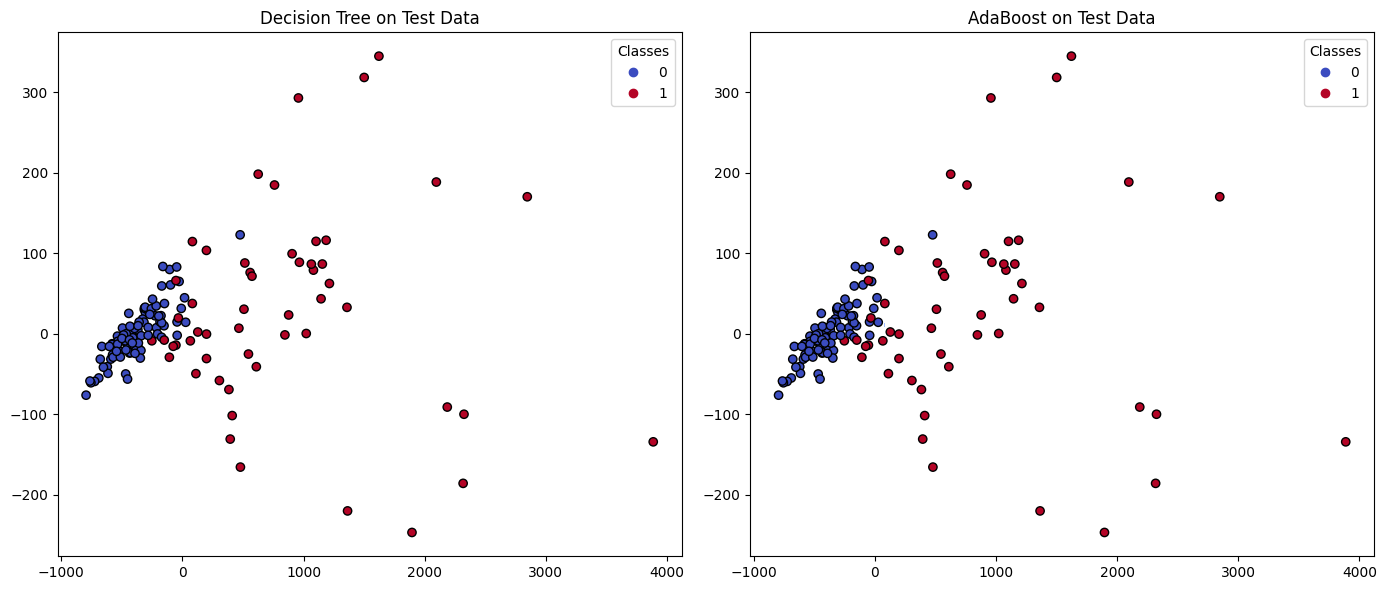


Comparison of Best Models:
           Model  Depth of Trees Number of Estimators  Training Accuracy  \
0  Decision Tree               3                  N/A           0.936620   
1       AdaBoost               1                  300           0.946009   

   Testing Accuracy       Bias-Variance Tradeoff  
0          0.923077  Low Bias, Moderate Variance  
1          0.944056       Low Bias, Low Variance  


In [8]:
# Step 6: Model Selection, Comparison, and Visualization

# Reduce the dataset to 2 dimensions using PCA for training and testing
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Fit on training data
X_test_pca = pca.transform(X_test)  # Transform test data

# Train the best Decision Tree model on PCA-transformed data
best_dt_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=50)
best_dt_model.fit(X_train_pca, y_train)

# Train the best AdaBoost model on PCA-transformed data
best_ab_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=50),
    n_estimators=300,
    learning_rate=0.5,
    random_state=50,
)
best_ab_model.fit(X_train_pca, y_train)

# Limit the dataset size for visualization (I had no choice due to the limitation of using RAM)
X_vis, y_vis = X_test_pca[:500], y_test[:500]  # Use only the first 500 samples for plotting


# Visualization of decision boundaries on test data
def plot_decision_boundary_test(model, X, y, title, ax):
    # Create a reduced mesh grid over a focused range (I had no choice due to the limitation of using RAM)
    x_min, x_max = X[:, 0].mean() - 3, X[:, 0].mean() + 3
    y_min, y_max = X[:, 1].mean() - 3, X[:, 1].mean() + 3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),  # Increased step size to 0.5
                         np.arange(y_min, y_max, 0.5))  # Increased step size to 0.5

    # Predict on the grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot the decision boundary
    ax.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    ax.set_title(title)
    ax.legend(*scatter.legend_elements(), title="Classes")

# Visualize decision boundaries on limited test data (I had no choice due to the limitation of using RAM)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Tree boundary
plot_decision_boundary_test(best_dt_model, X_vis, y_vis, "Decision Tree on Test Data", axes[0])

# AdaBoost boundary
plot_decision_boundary_test(best_ab_model, X_vis, y_vis, "AdaBoost on Test Data", axes[1])

plt.tight_layout()
plt.show()

# Detailed comparison of the best models
comparison = {
    "Model": ["Decision Tree", "AdaBoost"],
    "Depth of Trees": [3, 1],
    "Number of Estimators": ["N/A", 300],
    "Training Accuracy": [
        accuracy_score(y_train, best_dt_model.predict(X_train_pca)),
        accuracy_score(y_train, best_ab_model.predict(X_train_pca)),
    ],
    "Testing Accuracy": [
        accuracy_score(y_test, best_dt_model.predict(X_test_pca)),
        accuracy_score(y_test, best_ab_model.predict(X_test_pca)),
    ],
    "Bias-Variance Tradeoff": [
        "Low Bias, Moderate Variance",
        "Low Bias, Low Variance"
    ],
}

# Convert comparison to DataFrame for better visualization
comparison_df = pd.DataFrame(comparison)

# Display the comparison table
print("\nComparison of Best Models:")
print(comparison_df)
